# **FSMCNN-Based Accurate Fire Detection Using a Self-Modulative Convolutional Neural Network**

# Download Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("christofel04/fire-detection-dataset")

100%|██████████| 431M/431M [00:22<00:00, 20.2MB/s]

Extracting files...


# Import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import string
import os
import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [ ]:
import os
import tensorflow as tf

dataset_dir = os.path.join(path, "Fire Dataset PCD")

train_dir = os.path.join(dataset_dir, "Train")
test_dir = os.path.join(dataset_dir, "Test")

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['Neutral', 'Fire']
Test folders: ['Neutral', 'Fire']


# Data analysis

Total class distribution: {'Neutral': 1541, 'Fire': 1110}


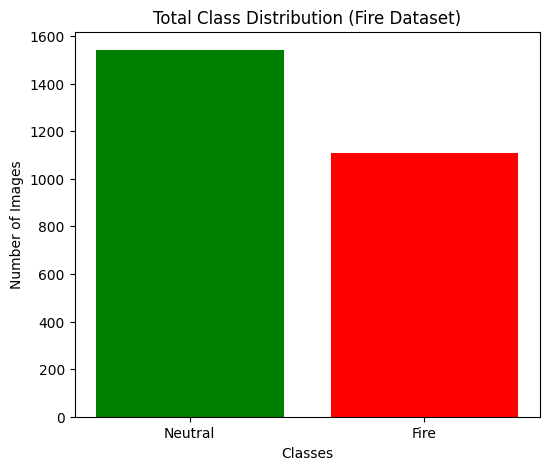

In [ ]:
import os
import matplotlib.pyplot as plt

# Count total images per class (Train + Test)
class_counts = {}

for cls in os.listdir(train_dir):
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    test_count = len(os.listdir(os.path.join(test_dir, cls)))
    class_counts[cls] = train_count + test_count

print("Total class distribution:", class_counts)

# Plot graph
classes = list(class_counts.keys())
values = list(class_counts.values())

plt.figure(figsize=(6,5))
plt.bar(classes, values, color=["green", "red"])  # Neutral=green, Fire=red

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Total Class Distribution (Fire Dataset)")

plt.show()

# Data Preprocessing

Processing Fire (Test): 100%|██████████| 123/123 [00:00<00:00, 644.12it/s]


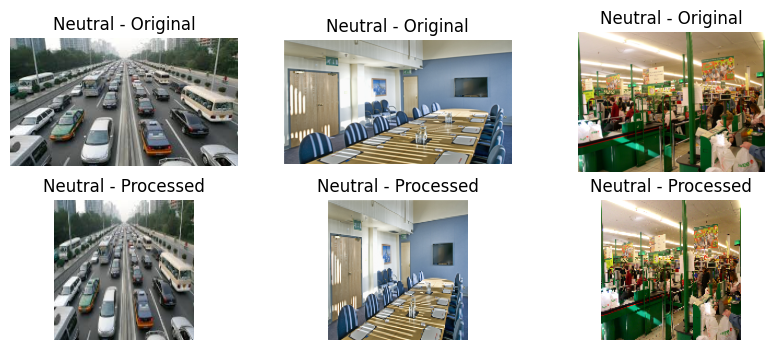

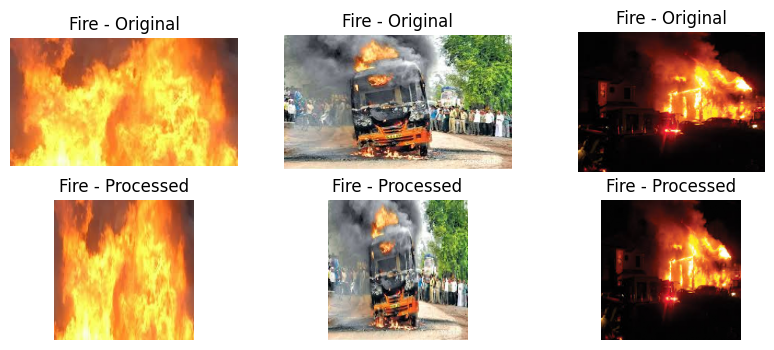

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

IMG_SIZE = 128

processed_images = []
labels = []
sample_display = {}

for split_dir in [train_dir, test_dir]:
    classes = os.listdir(split_dir)

    for cls in classes:

        class_path = os.path.join(split_dir, cls)
        images = os.listdir(class_path)

        display_count = 0

        for img_name in tqdm(images, desc=f"Processing {cls} ({os.path.basename(split_dir)})"):

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            original = img.copy()
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            processed_images.append(img)
            labels.append(cls)
            if cls not in sample_display:
                sample_display[cls] = []

            if len(sample_display[cls]) < 3:
                sample_display[cls].append((original, img))


# Display images
for cls in sample_display:

    plt.figure(figsize=(10,4))

    for i,(orig,prep) in enumerate(sample_display[cls]):

        plt.subplot(2,3,i+1)
        plt.imshow(orig)
        plt.title(f"{cls} - Original")
        plt.axis("off")

        plt.subplot(2,3,i+4)
        plt.imshow(prep)
        plt.title(f"{cls} - Processed")
        plt.axis("off")

    plt.show()


processed_images = np.array(processed_images)
labels = np.array(labels)


In [ ]:
import numpy as np
import os

save_path = "processed_fire_dataset"

os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "images.npy"), processed_images)
np.save(os.path.join(save_path, "labels.npy"), labels)

print("Dataset saved successfully!")


Dataset saved successfully!


# Split dataset

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
images = np.load("processed_fire_dataset/images.npy")
labels = np.load("processed_fire_dataset/labels.npy")

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

images, labels_encoded = shuffle(images, labels_encoded, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.2,
    stratify=labels_encoded,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2120, 128, 128, 3)
Test: (531, 128, 128, 3)


# Build Model

# Self Modulative Convolutional Neural Network


In [ ]:
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.25,
    shear_range=0.15,
    horizontal_flip=True
)

datagen.fit(X_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

def build_smcnn(input_shape=(128,128,3)):

    input_layer = Input(shape=input_shape)

    x = Conv2D(32, (3,3), activation='relu', padding='same')(input_layer)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    output_layer = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model



model = build_smcnn()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

#  Train Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 28s 270ms/step - accuracy: 0.7422 - loss: 0.5477 - val_accuracy: 0.5970 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.8695 - loss: 0.3009 - val_accuracy: 0.5819 - val_loss: 0.7811 - learning_rate: 0.0010
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.9091 - loss: 0.2276 - val_accuracy: 0.5819 - val_loss: 1.5434 - learning_rate: 0.0010
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 131ms/step - accuracy: 0.9202 - loss: 0.2311 - val_accuracy: 0.5819 - val_loss: 1.8572 - learning_rate: 0.0010
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 147ms/step - accuracy: 0.9273 - loss: 0.2134 - val_accuracy: 0.7759 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.9261 - loss: 0.1851 - val_accuracy: 0.8098 - val_loss: 0.4075 - learning_rate: 0.0010
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.9378 - loss: 0.1

# Model history

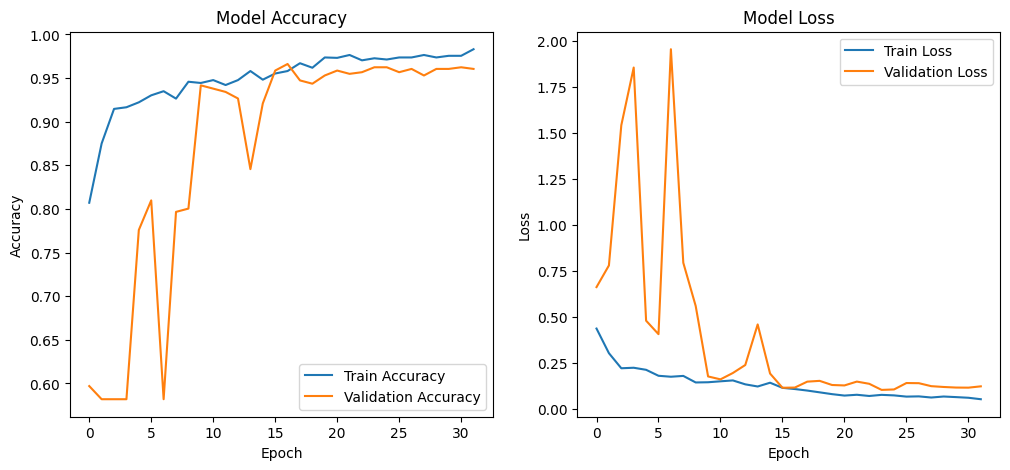

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Save Model

In [ ]:
model.save("fire_detection_smcnn.keras")

print("Model saved successfully!")

Model saved successfully!


# Confusion Matrix

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


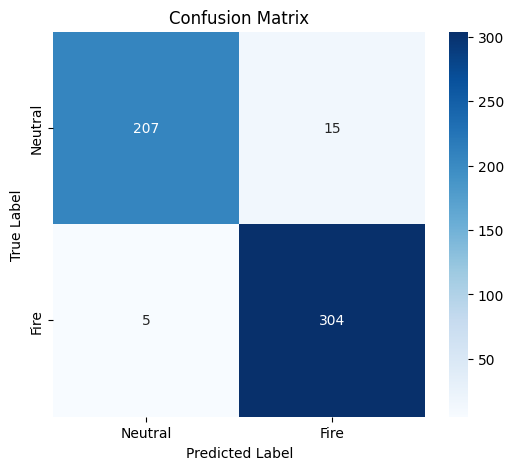

Classification Report:

              precision    recall  f1-score   support

     Neutral       0.98      0.93      0.95       222
        Fire       0.95      0.98      0.97       309

    accuracy                           0.96       531
   macro avg       0.96      0.96      0.96       531
weighted avg       0.96      0.96      0.96       531



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Neutral','Fire'],
    yticklabels=['Neutral','Fire']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Neutral','Fire']))

# Performance Metrics

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


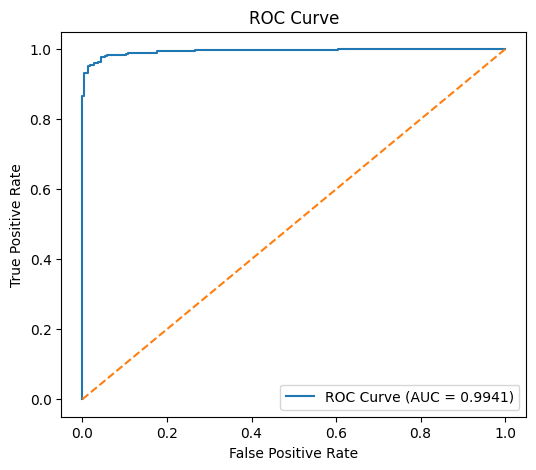

Performance Metrics
--------------------
Accuracy     : 0.9623
Precision    : 0.9530
Recall       : 0.9838
F1-Score     : 0.9682
Specificity  : 0.9324
ROC-AUC      : 0.9941
Error Rate   : 0.0377


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np


y_pred_prob = model.predict(X_test)


y_pred = (y_pred_prob > 0.5).astype(int)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
error_rate = 1 - accuracy


from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)

roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("Performance Metrics")
print("-" * 20)
print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-Score     : {f1:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")
print(f"Error Rate   : {error_rate:.4f}")

# Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


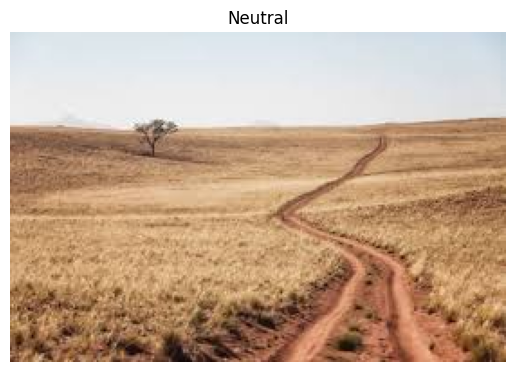

Prediction : Neutral


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load model
model = tf.keras.models.load_model("fire_detection_smcnn.keras")

IMG_SIZE = 128


labels = np.load("processed_fire_dataset/labels.npy")

le = LabelEncoder()
le.fit(labels)

image_path = "/content/ne.jpg"


img = cv2.imread(image_path)

if img is None:
    print("Invalid image path!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_resized = img_resized / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    # Predict
    pred = model.predict(img_resized)[0][0]

    # Convert prediction to class index
    pred_class = 1 if pred > 0.5 else 0
    label = le.inverse_transform([pred_class])[0]

    confidence = pred if pred > 0.5 else 1 - pred

    # Show image
    plt.imshow(img_rgb)
    plt.title(f"{label}")
    plt.axis("off")
    plt.show()

    print("Prediction :", label)
